<a href="https://www.kaggle.com/code/sonawanelalitsunil/anime-database-july-2025-ml-67-2?scriptVersionId=250939395" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/myanimelist-anime-database-july-2025/anime.csv


## Title:
Anime Database - July 2025

## Description:
The Anime Database (July 2025) is a curated collection of anime-related data compiled up to July 2025. It includes comprehensive information about popular anime series, movies, and characters, covering details such as titles, genres, release dates, ratings, studios, number of episodes, and more. This dataset is ideal for anime enthusiasts, data analysts, and developers aiming to explore trends in anime popularity, genre preferences, seasonal releases, or to build recommendation systems and visualization dashboards. Whether you're conducting academic research or building a fan project, this resource provides a solid foundation for anime data exploration and insights.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/myanimelist-anime-database-july-2025/anime.csv')

In [3]:
df.head()

,mal_id,url,approved,title,title_english,title_japanese,title_synonyms,image_jpg_url,image_jpg_small_url,image_jpg_large_url,...,broadcast_time,broadcast_timezone,broadcast_string,producers,licensors,studios,genres,explicit_genres,themes,demographics
0,1,https://myanimelist.net/anime/1/Cowboy_Bebop,True,Cowboy Bebop,Cowboy Bebop,カウボーイビバップ,NaN,https://cdn.myanimelist.net/images/anime/4/196...,https://cdn.myanimelist.net/images/anime/4/196...,https://cdn.myanimelist.net/images/anime/4/196...,...,01:00,Asia/Tokyo,Saturdays at 01:00 (JST),"Bandai Visual, Victor Entertainment, Audio Pla...",Funimation,Sunrise,"Action, Award Winning, Sci-Fi",NaN,"Adult Cast, Space",NaN
1,5,https://myanimelist.net/anime/5/Cowboy_Bebop__...,True,Cowboy Bebop: Tengoku no Tobira,Cowboy Bebop: The Movie,カウボーイビバップ 天国の扉,Cowboy Bebop: Knockin' on Heaven's Door,https://cdn.myanimelist.net/images/anime/1439/...,https://cdn.myanimelist.net/images/anime/1439/...,https://cdn.myanimelist.net/images/anime/1439/...,...,NaN,NaN,NaN,"Sunrise, Bandai Visual","Sony Pictures Entertainment, Funimation",Bones,"Action, Sci-Fi",NaN,"Adult Cast, Space",NaN
2,6,https://myanimelist.net/anime/6/Trigun,True,Trigun,Trigun,トライガン,NaN,https://cdn.myanimelist.net/images/anime/1130/...,https://cdn.myanimelist.net/images/anime/1130/...,https://cdn.myanimelist.net/images/anime/1130/...,...,01:15,Asia/Tokyo,Thursdays at 01:15 (JST),Victor Entertainment,Funimation,Madhouse,"Action, Adventure, Sci-Fi",NaN,Adult Cast,Shounen
3,7,https://myanimelist.net/anime/7/Witch_Hunter_R...,True,Witch Hunter Robin,Witch Hunter Robin,Witch Hunter ROBIN (ウイッチハンターロビン),WHR,https://cdn.myanimelist.net/images/anime/10/19...,https://cdn.myanimelist.net/images/anime/10/19...,https://cdn.myanimelist.net/images/anime/10/19...,...,01:25,Asia/Tokyo,Wednesdays at 01:25 (JST),"Bandai Visual, Dentsu, Victor Entertainment","Funimation, Bandai Entertainment",Sunrise,"Action, Drama, Mystery, Supernatural",NaN,Detective,NaN
4,8,https://myanimelist.net/anime/8/Bouken_Ou_Beet,True,Bouken Ou Beet,Beet the Vandel Buster,冒険王ビィト,Adventure King Beet,https://cdn.myanimelist.net/images/anime/7/215...,https://cdn.myanimelist.net/images/anime/7/215...,https://cdn.myanimelist.net/images/anime/7/215...,...,18:30,Asia/Tokyo,Thursdays at 18:30 (JST),"TV Tokyo, Dentsu",Illumitoon Entertainment,Toei Animation,"Action, Adventure, Fantasy",NaN,NaN,Shounen


In [4]:
df.tail()

,mal_id,url,approved,title,title_english,title_japanese,title_synonyms,image_jpg_url,image_jpg_small_url,image_jpg_large_url,...,broadcast_time,broadcast_timezone,broadcast_string,producers,licensors,studios,genres,explicit_genres,themes,demographics
28853,60010,https://myanimelist.net/anime/60010/Mad_Popcor...,True,Mad Popcorn World!,NaN,Mad POPCORN World!,NaN,https://cdn.myanimelist.net/images/anime/1760/...,https://cdn.myanimelist.net/images/anime/1760/...,https://cdn.myanimelist.net/images/anime/1760/...,...,NaN,NaN,NaN,NaN,NaN,Kitchen Ltd.,Avant Garde,NaN,Music,NaN
28854,60011,https://myanimelist.net/anime/60011/Saero_Gumi...,True,Saero Gumidyeon: San 257,NaN,새로구미뎐: 산 257,NaN,https://cdn.myanimelist.net/images/anime/1868/...,https://cdn.myanimelist.net/images/anime/1868/...,https://cdn.myanimelist.net/images/anime/1868/...,...,NaN,NaN,NaN,NaN,NaN,STUDIOK110,Fantasy,NaN,Historical,NaN
28855,60012,https://myanimelist.net/anime/60012/Re_Zero_ka...,True,Re:Zero kara Hajimeru Break Time 3rd Season,Re:ZERO ~Starting Break Time From Zero~ Season 3,Re:ゼロから始める休憩時間（ブレイクタイム）3rd season,Re:ZERO ~Starting Break Time From Zero~ 3rd Se...,https://cdn.myanimelist.net/images/anime/1349/...,https://cdn.myanimelist.net/images/anime/1349/...,https://cdn.myanimelist.net/images/anime/1349/...,...,NaN,NaN,NaN,NaN,NaN,Studio PuYUKAI,Comedy,NaN,NaN,NaN
28856,60012,https://myanimelist.net/anime/60012/Re_Zero_ka...,True,Re:Zero kara Hajimeru Break Time 3rd Season,Re:ZERO ~Starting Break Time From Zero~ Season 3,Re:ゼロから始める休憩時間（ブレイクタイム）3rd season,Re:ZERO ~Starting Break Time From Zero~ 3rd Se...,https://cdn.myanimelist.net/images/anime/1349/...,https://cdn.myanimelist.net/images/anime/1349/...,https://cdn.myanimelist.net/images/anime/1349/...,...,NaN,NaN,NaN,NaN,NaN,Studio PuYUKAI,Comedy,NaN,NaN,NaN
28857,60013,https://myanimelist.net/anime/60013/Onna_Gakus...,True,Onna Gakusei Nisshi,NaN,女學生日誌,Female Student's Diary,https://cdn.myanimelist.net/images/anime/1836/...,https://cdn.myanimelist.net/images/anime/1836/...,https://cdn.myanimelist.net/images/anime/1836/...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Music,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28858 entries, 0 to 28857
Data columns (total 58 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   mal_id                     28858 non-null  int64  
 1   url                        28858 non-null  object 
 2   approved                   28858 non-null  bool   
 3   title                      28858 non-null  object 
 4   title_english              12435 non-null  object 
 5   title_japanese             28737 non-null  object 
 6   title_synonyms             14266 non-null  object 
 7   image_jpg_url              28858 non-null  object 
 8   image_jpg_small_url        28858 non-null  object 
 9   image_jpg_large_url        28858 non-null  object 
 10  image_webp_url             28858 non-null  object 
 11  image_webp_small_url       28858 non-null  object 
 12  image_webp_large_url       28858 non-null  object 
 13  trailer_youtube_id         5553 non-null   obj

In [6]:
df.describe()

,mal_id,episodes,score,scored_by,rank,popularity,members,favorites,aired_prop_from_day,aired_prop_from_month,aired_prop_from_year,aired_prop_to_day,aired_prop_to_month,aired_prop_to_year,year,explicit_genres
count,28858.000000,28110.000000,18735.000000,1.873500e+04,21942.000000,28858.000000,2.885800e+04,28858.000000,27924.000000,27924.000000,27924.000000,11115.000000,11115.000000,11115.000000,6220.000000,0.0
mean,33836.805115,14.152650,6.399964,2.986903e+04,10887.761781,14312.554889,3.851955e+04,429.068889,12.248496,5.771057,2009.106074,19.299055,6.649303,2011.178048,2009.940675,NaN
std,19541.043159,47.316621,0.890979,1.213790e+05,6267.613988,8263.760798,1.661821e+05,4491.188858,9.828714,3.683701,15.066418,9.169489,3.582280,11.608974,13.197530,NaN
min,1.000000,1.000000,1.890000,1.010000e+02,1.000000,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1917.000000,1.000000,1.000000,1962.000000,1961.000000,NaN
25%,15220.500000,1.000000,5.780000,3.405000e+02,5453.500000,7150.250000,2.350000e+02,0.000000,3.000000,2.000000,2004.000000,13.000000,3.000000,2006.000000,2004.000000,NaN
50%,37882.500000,2.000000,6.370000,1.545000e+03,10917.500000,14304.500000,1.083500e+03,1.000000,10.000000,6.000000,2014.000000,22.000000,6.000000,2014.000000,2014.000000,NaN
75%,50239.750000,13.000000,7.030000,1.011600e+04,16502.750000,21466.000000,9.231750e+03,17.000000,21.000000,9.000000,2019.000000,26.000000,9.000000,2020.000000,2020.000000,NaN
max,62055.000000,3057.000000,9.300000,2.954863e+06,21844.000000,28628.000000,4.192911e+06,240193.000000,31.000000,12.000000,2027.000000,31.000000,12.000000,2026.000000,2026.000000,NaN


In [7]:
df.dtypes

mal_id                         int64
url                           object
approved                        bool
title                         object
title_english                 object
title_japanese                object
title_synonyms                object
image_jpg_url                 object
image_jpg_small_url           object
image_jpg_large_url           object
image_webp_url                object
image_webp_small_url          object
image_webp_large_url          object
trailer_youtube_id            object
trailer_url                   object
trailer_embed_url             object
trailer_image_url             object
trailer_small_image_url       object
trailer_medium_image_url      object
trailer_large_image_url       object
trailer_maximum_image_url     object
type                          object
source                        object
episodes                     float64
status                        object
airing                          bool
duration                      object
r

In [8]:
df.shape

(28858, 58)

In [9]:
df.isnull().sum()

mal_id                           0
url                              0
approved                         0
title                            0
title_english                16423
title_japanese                 121
title_synonyms               14592
image_jpg_url                    0
image_jpg_small_url              0
image_jpg_large_url              0
image_webp_url                   0
image_webp_small_url             0
image_webp_large_url             0
trailer_youtube_id           23305
trailer_url                  23305
trailer_embed_url            23304
trailer_image_url            23305
trailer_small_image_url      23305
trailer_medium_image_url     23305
trailer_large_image_url      23305
trailer_maximum_image_url    23305
type                            81
source                           0
episodes                       748
status                           0
airing                           0
duration                         0
rating                         639
score               

In [10]:
df.duplicated().sum()

231

In [11]:
df.columns

Index(['mal_id', 'url', 'approved', 'title', 'title_english', 'title_japanese',
       'title_synonyms', 'image_jpg_url', 'image_jpg_small_url',
       'image_jpg_large_url', 'image_webp_url', 'image_webp_small_url',
       'image_webp_large_url', 'trailer_youtube_id', 'trailer_url',
       'trailer_embed_url', 'trailer_image_url', 'trailer_small_image_url',
       'trailer_medium_image_url', 'trailer_large_image_url',
       'trailer_maximum_image_url', 'type', 'source', 'episodes', 'status',
       'airing', 'duration', 'rating', 'score', 'scored_by', 'rank',
       'popularity', 'members', 'favorites', 'synopsis', 'background',
       'aired_from', 'aired_to', 'aired_prop_from_day',
       'aired_prop_from_month', 'aired_prop_from_year', 'aired_prop_to_day',
       'aired_prop_to_month', 'aired_prop_to_year', 'aired_string', 'season',
       'year', 'broadcast_day', 'broadcast_time', 'broadcast_timezone',
       'broadcast_string', 'producers', 'licensors', 'studios', 'genres',
    

## Data visualizations

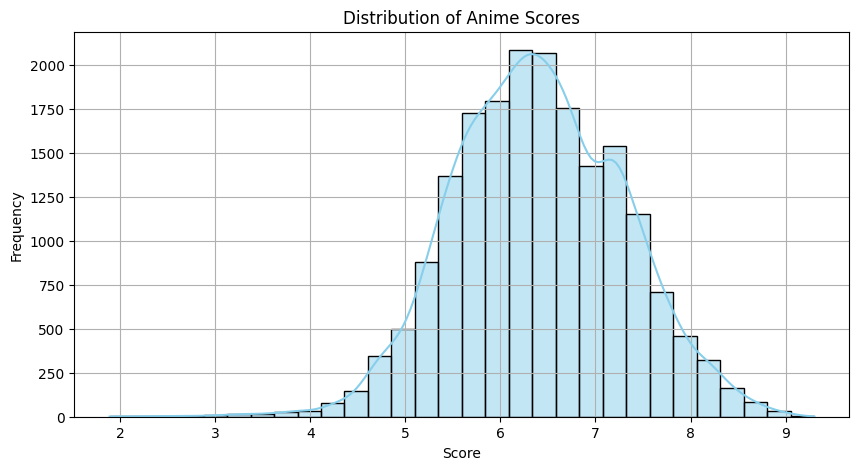

In [12]:
plt.figure(figsize=(10, 5))
sns.histplot(df['score'].dropna(), bins=30, kde=True, color='skyblue')
plt.title('Distribution of Anime Scores')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

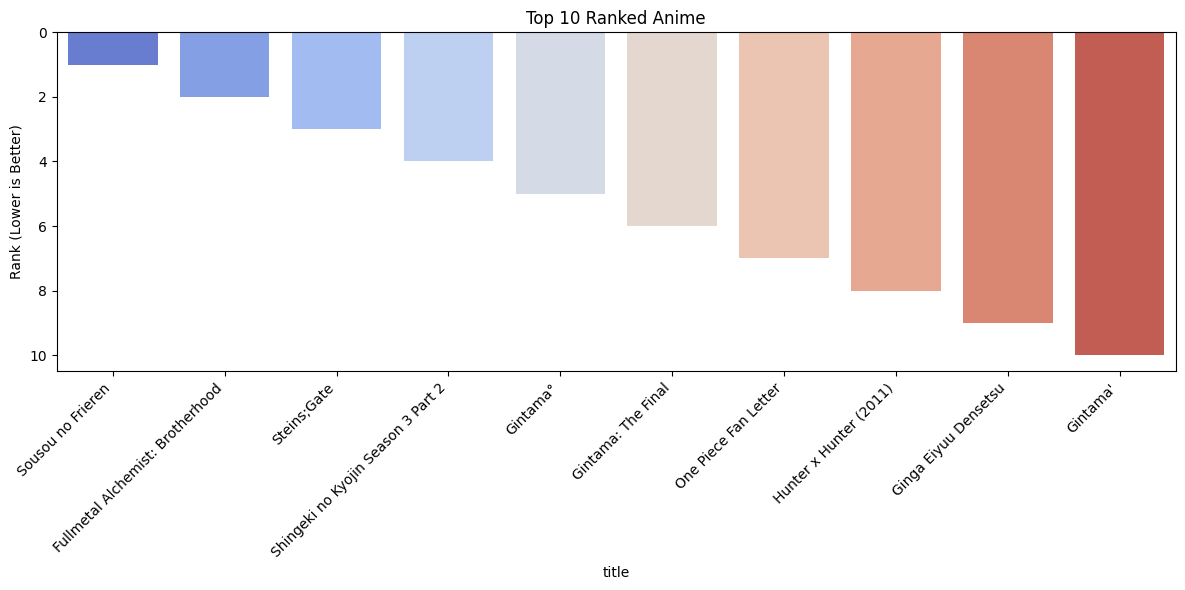

In [13]:
top_ranked = df[df['rank'].notna()].sort_values(by='rank').head(10)
plt.figure(figsize=(12, 6))
sns.barplot(data=top_ranked, x='title', y='rank', palette='coolwarm')
plt.title('Top 10 Ranked Anime')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Rank (Lower is Better)')
plt.gca().invert_yaxis()  # Rank 1 is best
plt.tight_layout()
plt.show()


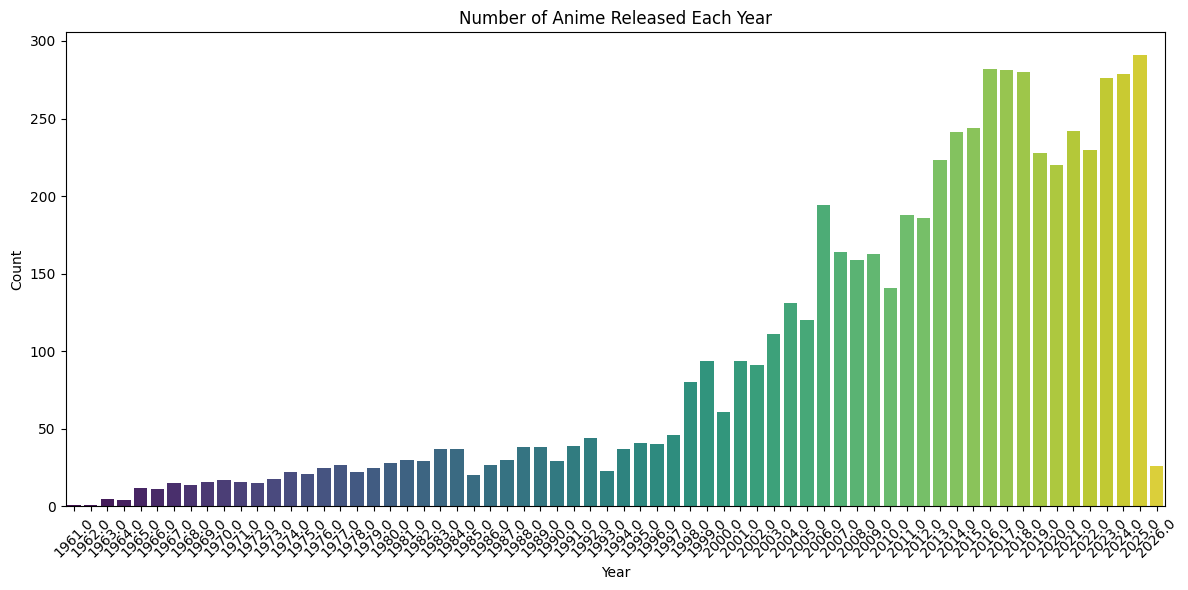

In [14]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df[df['year'].notna()], x='year', order=sorted(df['year'].dropna().unique()), palette='viridis')
plt.title('Number of Anime Released Each Year')
plt.xticks(rotation=45)
plt.ylabel('Count')
plt.xlabel('Year')
plt.tight_layout()
plt.show()


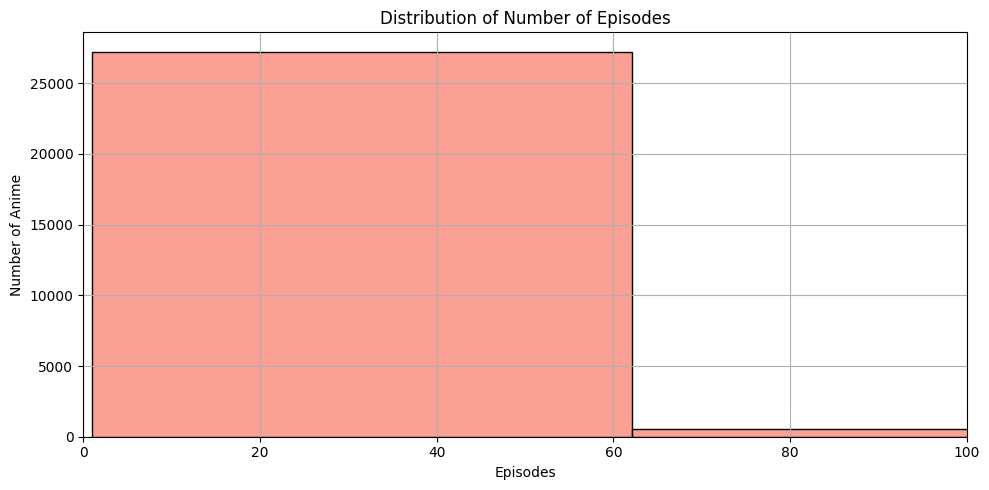

In [15]:
plt.figure(figsize=(10, 5))
sns.histplot(df['episodes'].dropna(), bins=50, color='salmon')
plt.title('Distribution of Number of Episodes')
plt.xlabel('Episodes')
plt.ylabel('Number of Anime')
plt.xlim(0, 100)  # Ignore very large episode counts for clarity
plt.grid(True)
plt.tight_layout()
plt.show()


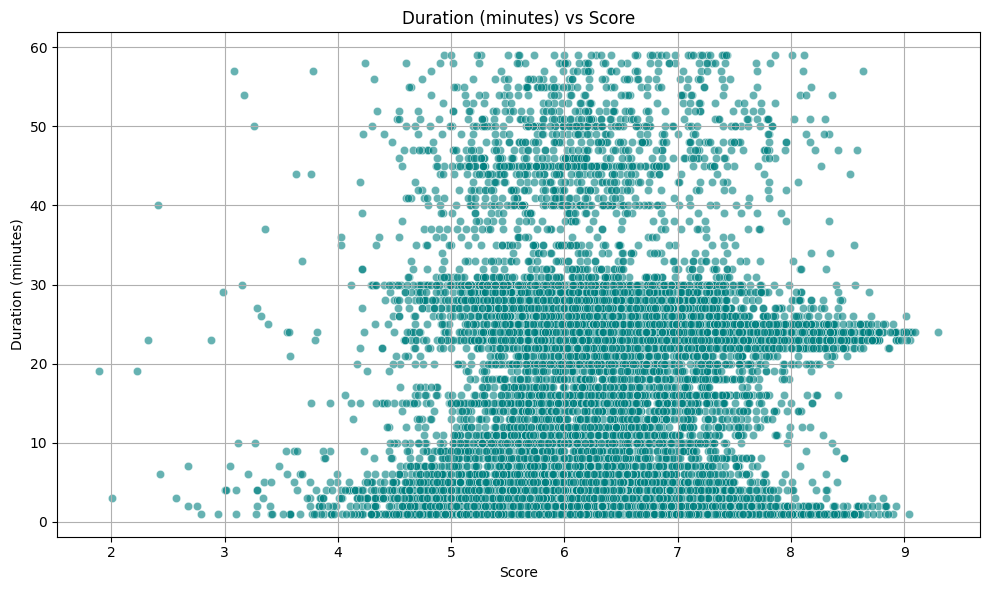

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df[df['duration'].notna() & df['score'].notna()], 
                x='score', y=df['duration'].apply(lambda x: int(x.split()[0]) if x.split()[0].isdigit() else None),
                alpha=0.6, color='teal')
plt.title('Duration (minutes) vs Score')
plt.xlabel('Score')
plt.ylabel('Duration (minutes)')
plt.grid(True)
plt.tight_layout()
plt.show()


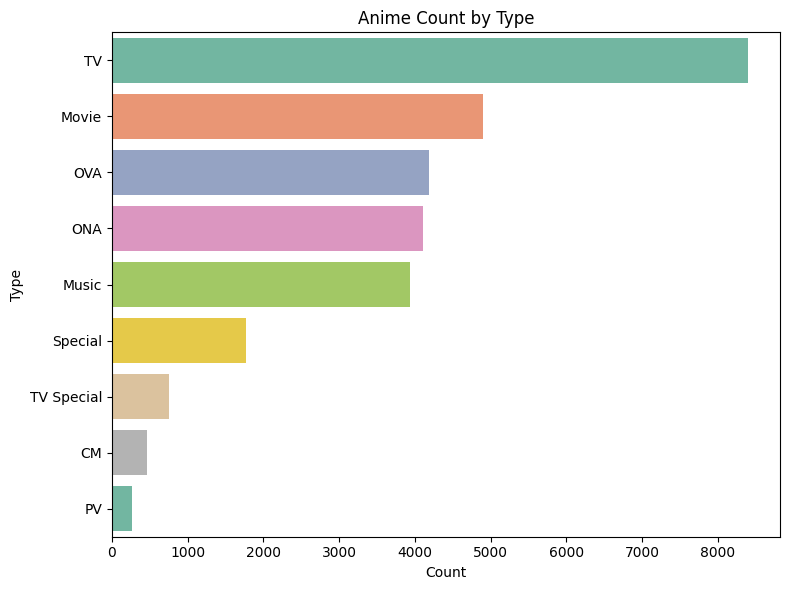

In [17]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df[df['type'].notna()], y='type', order=df['type'].value_counts().index, palette='Set2')
plt.title('Anime Count by Type')
plt.xlabel('Count')
plt.ylabel('Type')
plt.tight_layout()
plt.show()


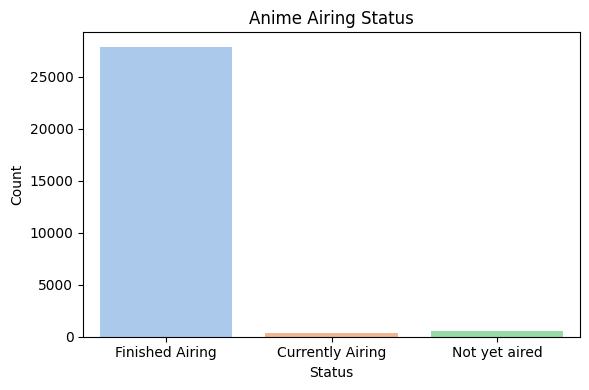

In [18]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df[df['status'].notna()], x='status', palette='pastel')
plt.title('Anime Airing Status')
plt.xlabel('Status')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


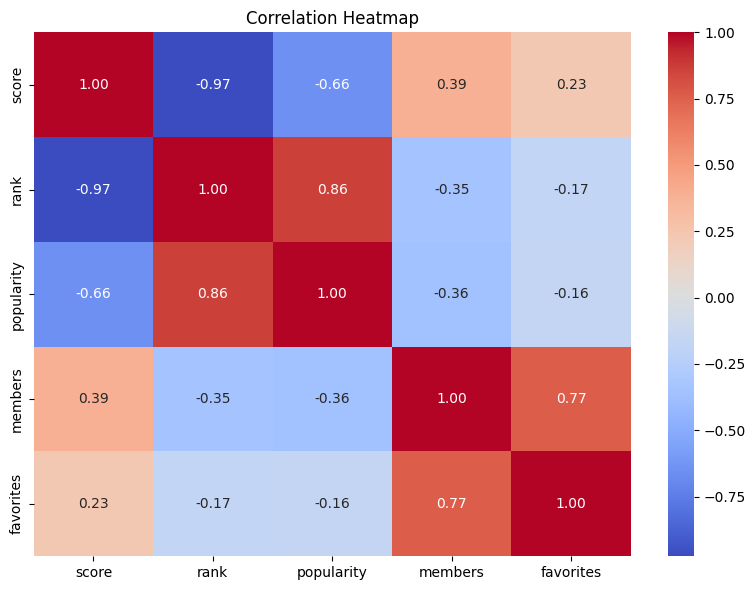

In [19]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[['score', 'rank', 'popularity', 'members', 'favorites']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


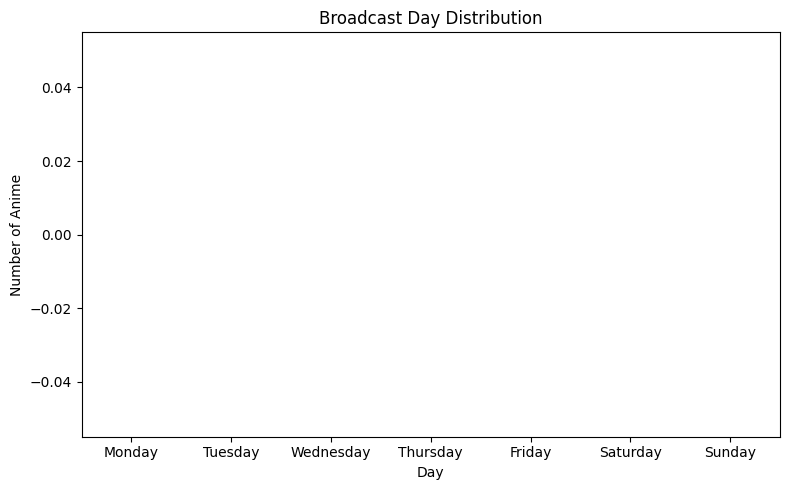

In [20]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df[df['broadcast_day'].notna()], x='broadcast_day', order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], palette='cubehelix')
plt.title('Broadcast Day Distribution')
plt.xlabel('Day')
plt.ylabel('Number of Anime')
plt.tight_layout()
plt.show()


## Predictive modeling

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer

# ML Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [22]:
# Choose target and relevant features
features = ['type', 'source', 'episodes', 'score', 'rank', 'popularity', 'members', 'favorites', 'season', 'year']
target = 'rating'

df = df[features + [target]].dropna(subset=[target])  # Drop rows where target is null

# Fill missing numerical values with median
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = SimpleImputer(strategy='median').fit_transform(df[num_cols])

# Encode categorical columns
cat_cols = df.select_dtypes(include='object').columns
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [23]:
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [24]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Support Vector Machine": SVC(),
    "Naive Bayes": GaussianNB(),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

accuracy_results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    accuracy = accuracy_score(y_test, preds) * 100
    accuracy_results[name] = round(accuracy, 2)


In [25]:
print("Model Accuracy Scores (on Test Set):\n")
for name, acc in accuracy_results.items():
    print(f"{name}: {acc}%")


Model Accuracy Scores (on Test Set):

Logistic Regression: 54.78%
Decision Tree: 58.59%
Random Forest: 67.08%
Support Vector Machine: 51.4%
Naive Bayes: 44.19%
K-Nearest Neighbors: 57.23%


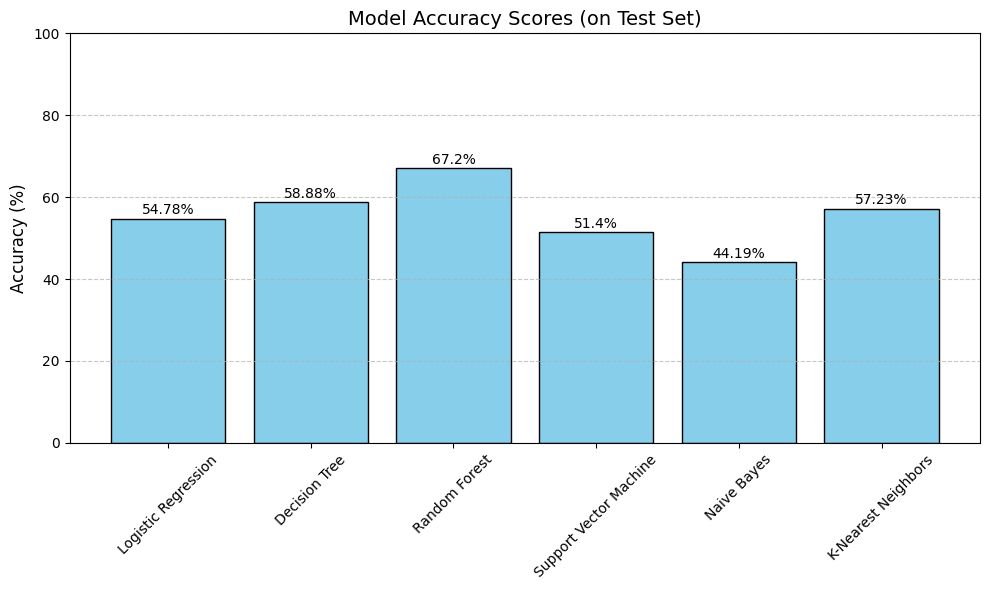

In [26]:
accuracy_results = {
    "Logistic Regression": 54.78,
    "Decision Tree": 58.88,
    "Random Forest": 67.2,
    "Support Vector Machine": 51.4,
    "Naive Bayes": 44.19,
    "K-Nearest Neighbors": 57.23
}

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(accuracy_results.keys(), accuracy_results.values(), color='skyblue', edgecolor='black')
plt.title("Model Accuracy Scores (on Test Set)", fontsize=14)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.ylim(0, 100)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate bars
for i, (model, score) in enumerate(accuracy_results.items()):
    plt.text(i, score + 1, f"{score}%", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## Thank you ...pls upvote!!!